# Task 2: Customer Segmentation Using Unsupervised Learning

## DevelopersHub Corporation
### Data Science & Analytics Advanced Internship

## Problem Statement

Businesses have customers with different income levels and spending behaviors. 
Using the same marketing strategy for every customer may not be effective.

This project uses unsupervised machine learning to divide customers into meaningful groups based on their characteristics and spending habits.

## Objective

The objectives of this project are to:

- Conduct Exploratory Data Analysis (EDA)
- Analyze customer spending behavior
- Apply K-Means Clustering
- Determine an appropriate number of clusters
- Use PCA to visualize customer clusters
- Profile each customer segment
- Suggest relevant marketing strategies for each identified segment

## Dataset

Mall Customers Dataset

In [1]:
# Install required libraries if needed
%pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Load the Dataset

The Mall Customers Dataset is loaded using pandas. 
The first few rows are displayed to verify that the dataset has been loaded correctly.

In [3]:
# Load the dataset

df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,52,35,60
1,2,Male,68,16,71
2,3,Female,54,74,23
3,4,Female,38,37,54
4,5,Female,18,26,39


## 2. Initial Data Inspection

The dataset is inspected to understand:

- Number of rows and columns
- Column names
- Data types
- Dataset structure
- Summary statistics

In [4]:
# Display dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 5


In [5]:
# Display column names

print("Column Names:")

for column in df.columns:
    print("-", column)

Column Names:
- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)


In [6]:
# Display first five rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,52,35,60
1,2,Male,68,16,71
2,3,Female,54,74,23
3,4,Female,38,37,54
4,5,Female,18,26,39


In [7]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
# Display descriptive statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,39.24,11.980822,18.0,29.75,39.5,47.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,64.785,36.863442,15.0,30.75,63.0,94.0,132.0
Spending Score (1-100),200.0,NaN,NaN,NaN,51.275,29.004234,1.0,29.0,52.0,77.25,98.0


## 3. Data Cleaning and Preprocessing

Before clustering, the dataset is checked for:

- Missing values
- Duplicate records
- Incorrect data types
- Data quality issues

Clean data is important for reliable customer segmentation.

In [10]:
# Check missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df) * 100).round(2)
})

missing_table

,Missing Values,Percentage (%)
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
Annual Income (k$),0,0.0
Spending Score (1-100),0,0.0


In [11]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Remove duplicate rows if any exist

rows_before = len(df)

df = df.drop_duplicates().copy()

rows_after = len(df)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before cleaning: 200
Rows after cleaning: 200
Duplicates removed: 0


In [13]:
# Check missing values after cleaning

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to understand:

- Customer demographics
- Age distribution
- Annual income distribution
- Spending score distribution
- Relationships between income and spending
- Correlations between numerical features
- Potential outliers

In [14]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical Columns:
['Gender']


Task was destroyed but it is pending!
task: <Task pending name='Task-131' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-132' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-132' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


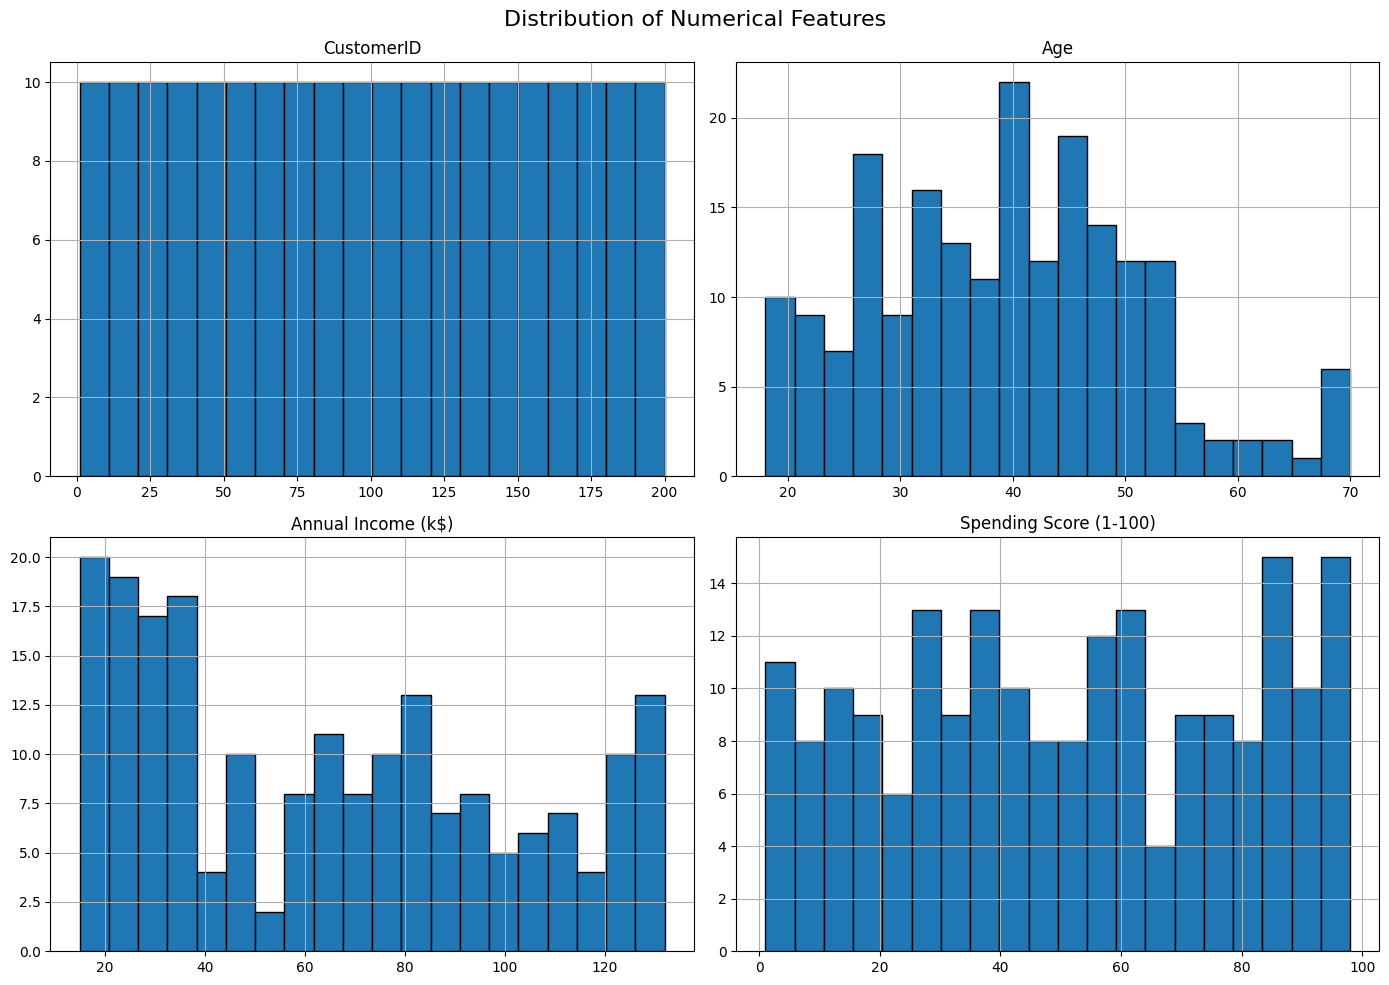

In [15]:
# Plot numerical feature distributions

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

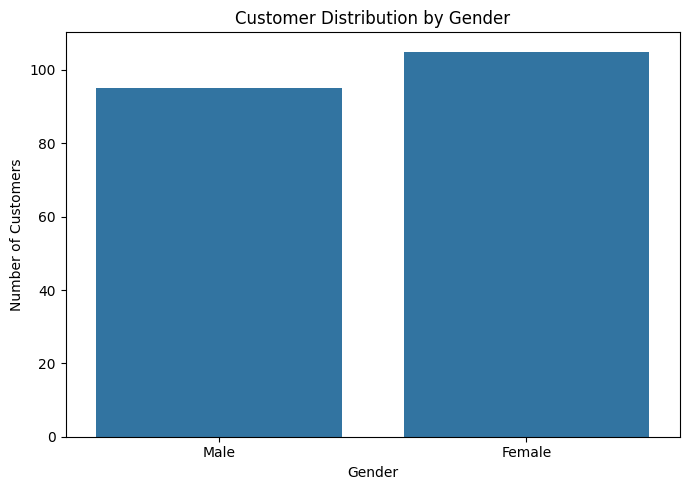

In [16]:
# Gender distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

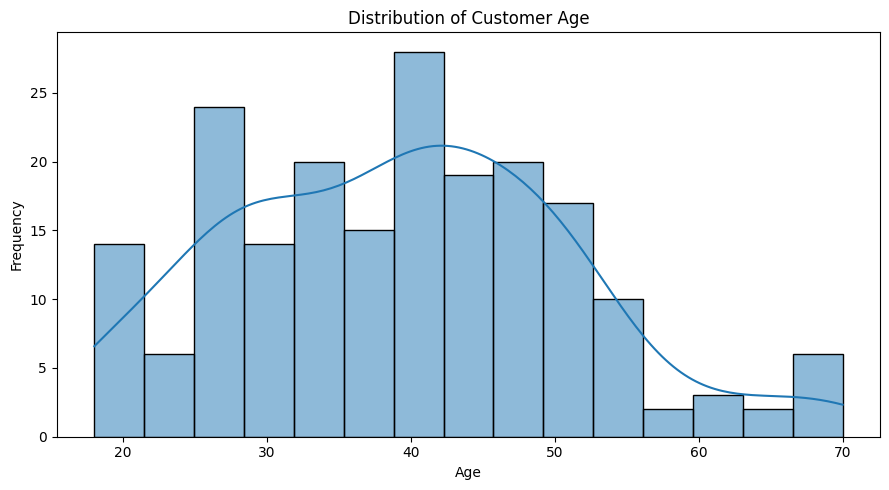

In [17]:
# Age distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

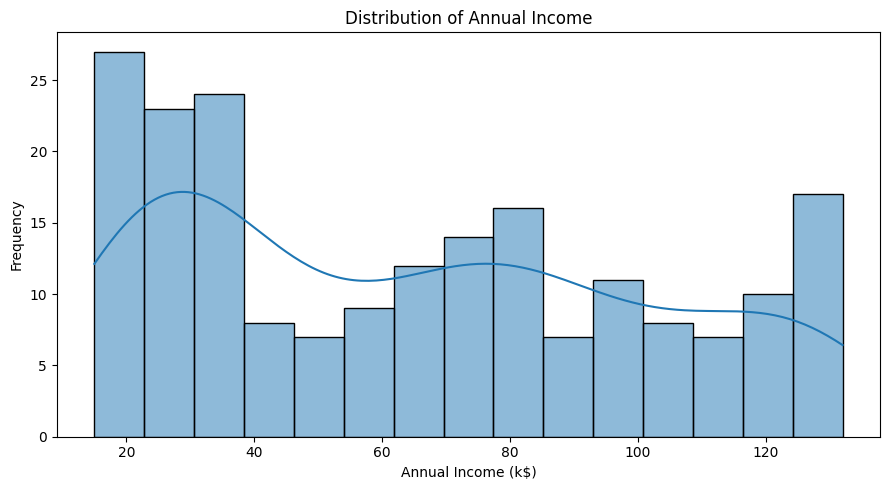

In [18]:
# Annual Income distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=15,
    kde=True
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

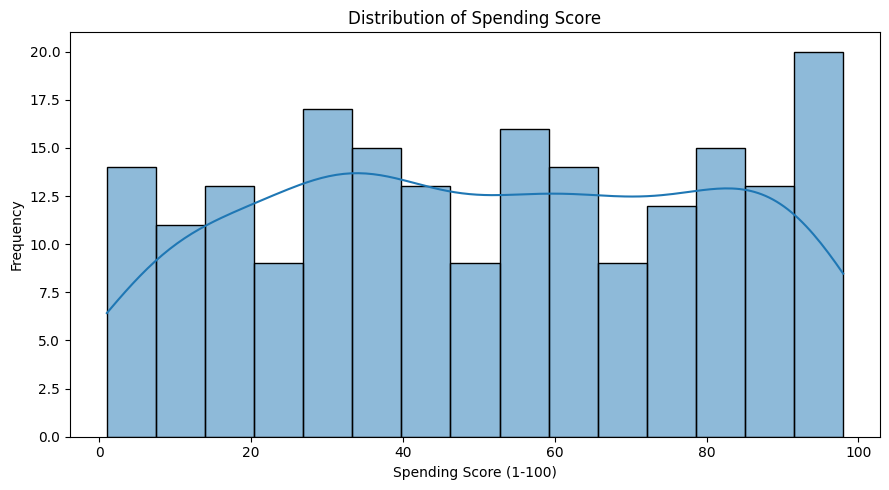

In [19]:
# Spending Score distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=15,
    kde=True
)

plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

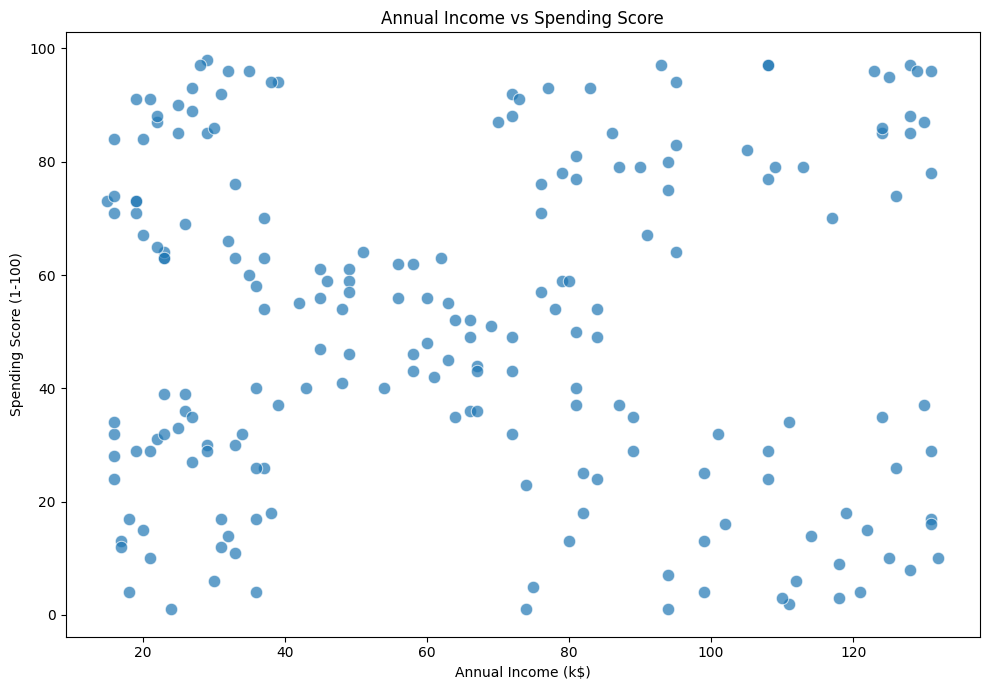

In [20]:
# Annual Income vs Spending Score

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=80,
    alpha=0.7
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

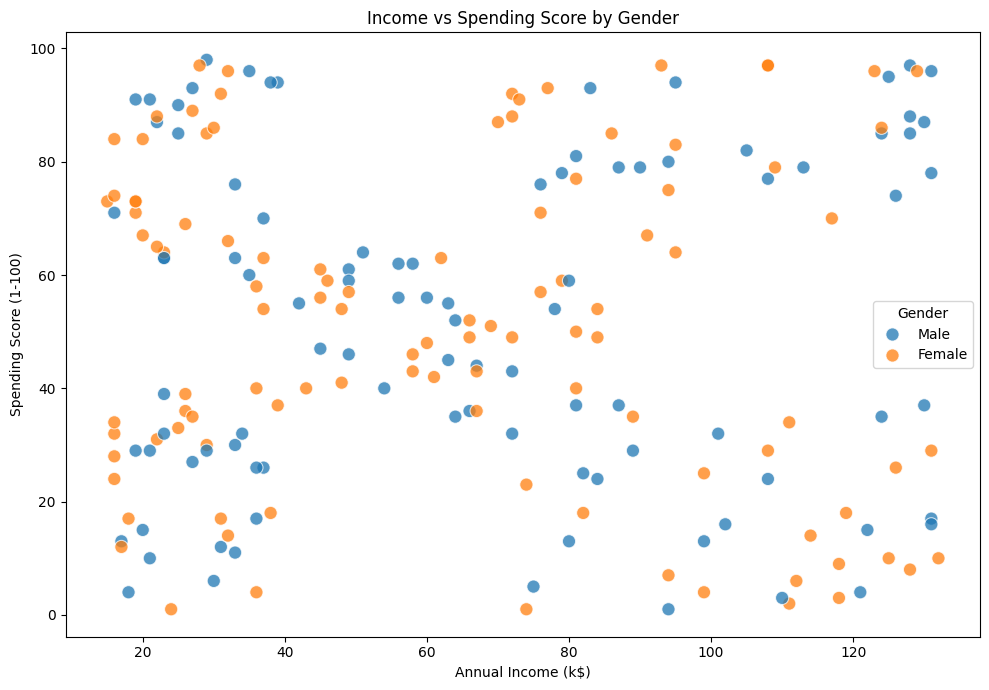

In [21]:
# Annual Income vs Spending Score by Gender

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=90,
    alpha=0.75
)

plt.title("Income vs Spending Score by Gender")

plt.tight_layout()
plt.show()

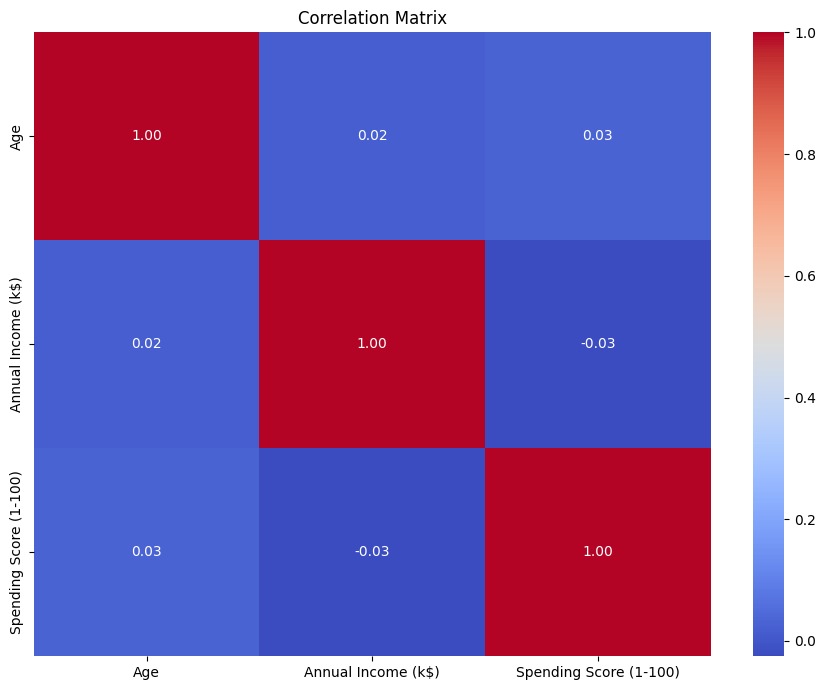

In [22]:
# Correlation matrix

numeric_df = df.select_dtypes(include=np.number)

# Remove CustomerID because it is only an identifier
if "CustomerID" in numeric_df.columns:
    numeric_df = numeric_df.drop(
        columns=["CustomerID"]
    )

plt.figure(figsize=(9, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

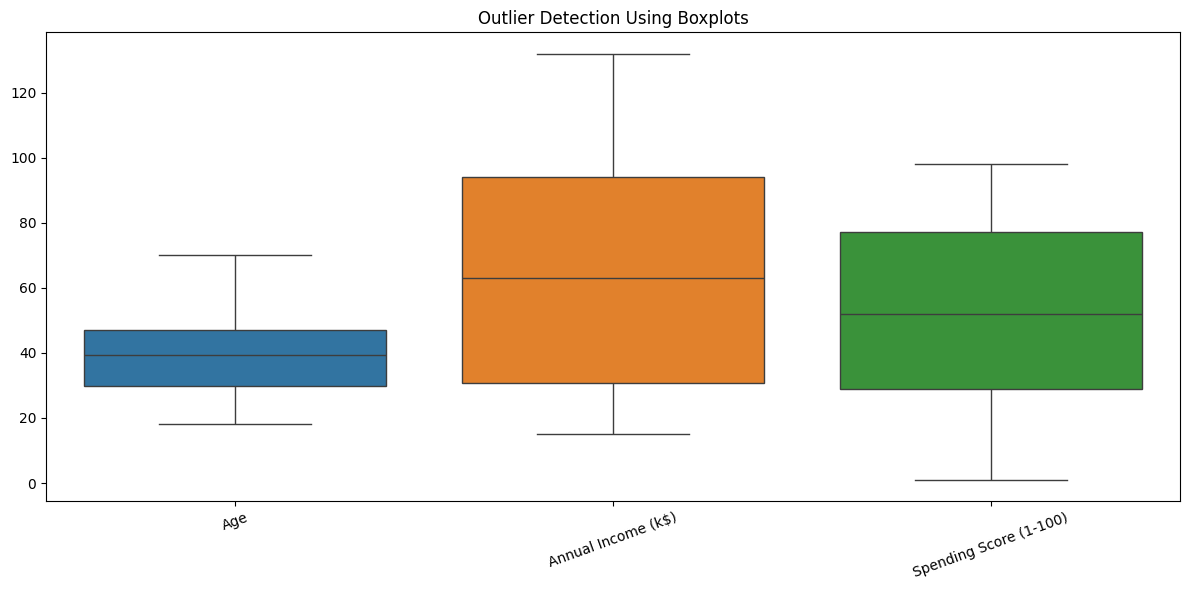

In [23]:
# Boxplots for outlier detection

features_for_boxplot = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[features_for_boxplot]
)

plt.title("Outlier Detection Using Boxplots")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 5. Feature Selection

For customer segmentation, the following features are selected:

- Annual Income (k$)
- Spending Score (1-100)

### Reason for Selection

Annual Income represents the customer's purchasing capacity.

Spending Score represents the customer's spending behavior.

Together, these features can reveal meaningful customer groups for targeted marketing strategies.

CustomerID is excluded because it is only an identifier and does not represent customer behavior.

In [24]:
# Select clustering features

features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Dataset Shape:")
print(X.shape)

X.head()

Selected Features:
['Annual Income (k$)', 'Spending Score (1-100)']

Feature Dataset Shape:
(200, 2)


,Annual Income (k$),Spending Score (1-100)
0,35,60
1,16,71
2,74,23
3,37,54
4,26,39


In [25]:
# Check selected features

print("Missing Values:")
print(X.isnull().sum())

print("\nDescriptive Statistics:")
display(X.describe().T)

Missing Values:
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Annual Income (k$),200.0,64.785,36.863442,15.0,30.75,63.0,94.00,132.0
Spending Score (1-100),200.0,51.275,29.004234,1.0,29.00,52.0,77.25,98.0


## 6. Feature Scaling

K-Means Clustering is a distance-based algorithm.

StandardScaler is applied to ensure that the selected features contribute fairly to the clustering process.

Feature scaling prevents variables with larger numerical ranges from dominating the distance calculations.

In [26]:
# Apply StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("Feature scaling completed successfully!")

X_scaled_df.head()

Task was destroyed but it is pending!
task: <Task pending name='Task-202' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-203' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-203' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Feature scaling completed successfully!


,Annual Income (k$),Spending Score (1-100)
0,-0.810010,0.301573
1,-1.326719,0.681780
2,0.250604,-0.977304
3,-0.755619,0.094188
4,-1.054767,-0.424276


In [27]:
# Check scaled feature statistics

X_scaled_df.describe().round(3)

,Annual Income (k$),Spending Score (1-100)
count,200.000,200.000
mean,0.000,0.000
std,1.003,1.003
min,-1.354,-1.738
25%,-0.926,-0.770
50%,-0.049,0.025
75%,0.795,0.898
max,1.828,1.615


## 7. Determine the Optimal Number of Clusters

Two methods are used:

1. Elbow Method
2. Silhouette Score

The Elbow Method examines the Within-Cluster Sum of Squares.

The Silhouette Score measures how well customers fit within their assigned clusters compared with neighboring clusters.

Using both techniques provides stronger evidence for selecting an appropriate number of customer segments.

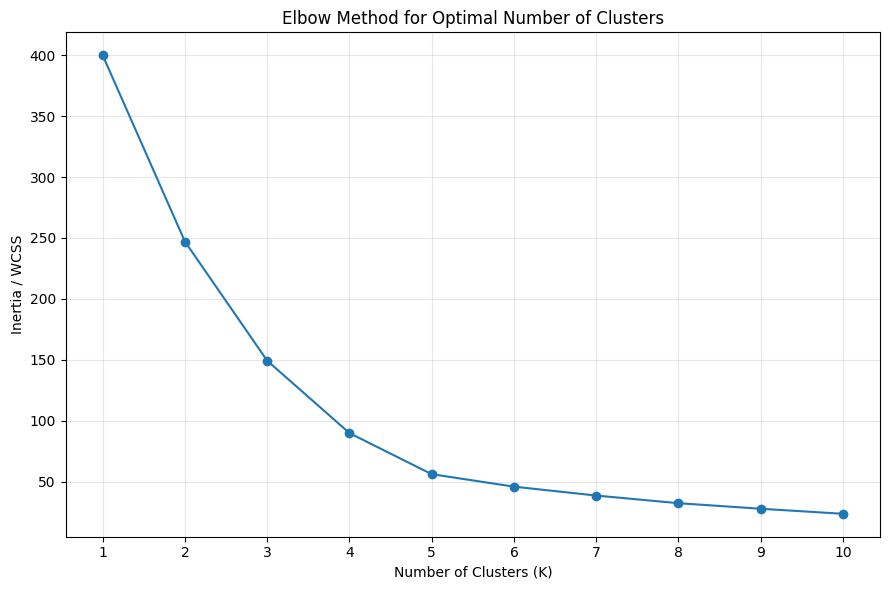

In [28]:
# Elbow Method

inertia_values = []

k_range = range(1, 11)

for k in k_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia_values.append(
        kmeans.inertia_
    )

plt.figure(figsize=(9, 6))

plt.plot(
    list(k_range),
    inertia_values,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal Number of Clusters"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")

plt.xticks(list(k_range))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Calculate Silhouette Scores

silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(
        X_scaled
    )
    
    score = silhouette_score(
        X_scaled,
        cluster_labels
    )
    
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,Number of Clusters,Silhouette Score
0,2,0.365226
1,3,0.440032
2,4,0.467497
3,5,0.521239
4,6,0.514441
5,7,0.485592
6,8,0.462854
7,9,0.458446
8,10,0.454556


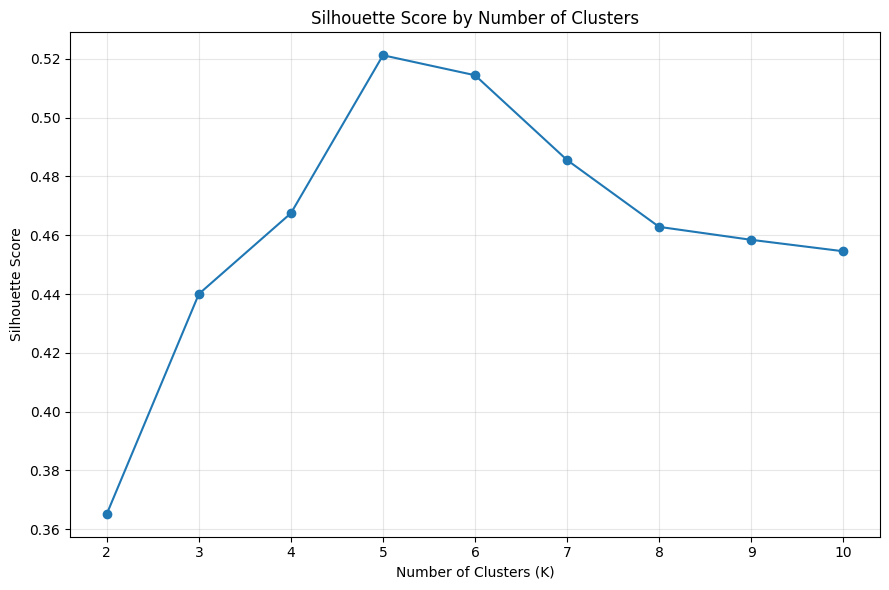

In [30]:
# Plot Silhouette Scores

plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title(
    "Silhouette Score by Number of Clusters"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Find best K automatically

best_k = silhouette_results.loc[
    silhouette_results["Silhouette Score"].idxmax(),
    "Number of Clusters"
]

best_score = silhouette_results[
    "Silhouette Score"
].max()

print(
    "Best Number of Clusters:",
    best_k
)

print(
    "Best Silhouette Score:",
    round(best_score, 4)
)

Best Number of Clusters: 5
Best Silhouette Score: 0.5212


## 8. Build the Final K-Means Clustering Model

The final K-Means model is trained using the selected number of clusters.

The number of clusters is supported by:

- Elbow Method
- Silhouette Score
- Business interpretability

In [32]:
# Select final number of clusters

final_k = int(best_k)

print(
    "Final selected number of clusters:",
    final_k
)

Final selected number of clusters: 5


In [33]:
# Train final K-Means model

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(
    X_scaled
)

print(
    "K-Means clustering completed successfully!"
)

df.head()

K-Means clustering completed successfully!


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,52,35,60,4
1,2,Male,68,16,71,4
2,3,Female,54,74,23,2
3,4,Female,38,37,54,3
4,5,Female,18,26,39,0


In [34]:
# Count customers in each cluster

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = [
    "Cluster",
    "Number of Customers"
]

cluster_counts

,Cluster,Number of Customers
0,0,37
1,1,39
2,2,37
3,3,50
4,4,37


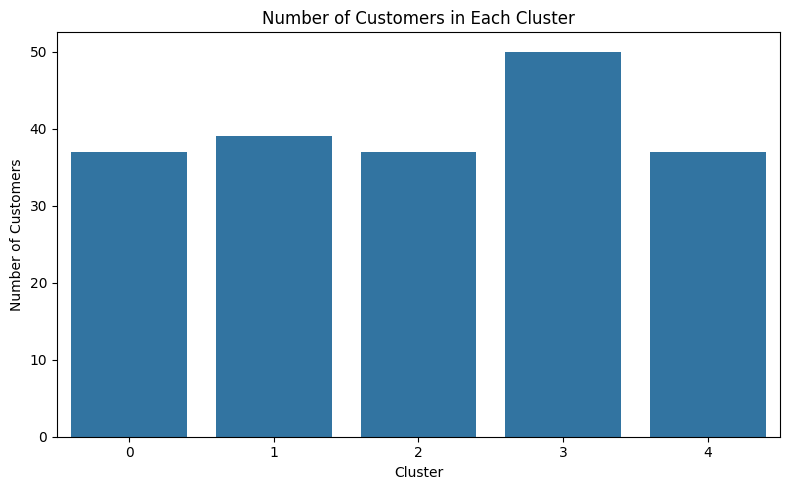

In [35]:
# Visualize cluster sizes

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_counts,
    x="Cluster",
    y="Number of Customers"
)

plt.title(
    "Number of Customers in Each Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 9. Visualize Customer Clusters

The identified customer segments are visualized using Annual Income and Spending Score.

Each color represents a different customer cluster identified by the K-Means algorithm.

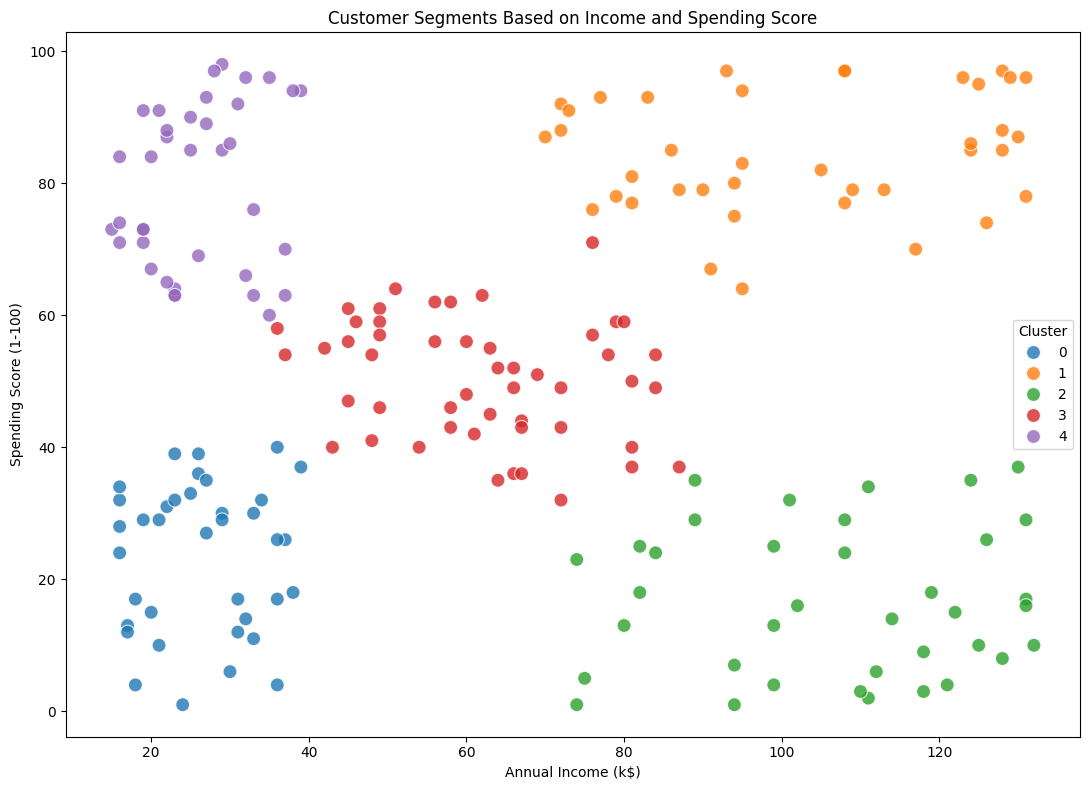

In [36]:
# Visualize customer clusters

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=100,
    alpha=0.8
)

plt.title(
    "Customer Segments Based on Income and Spending Score"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

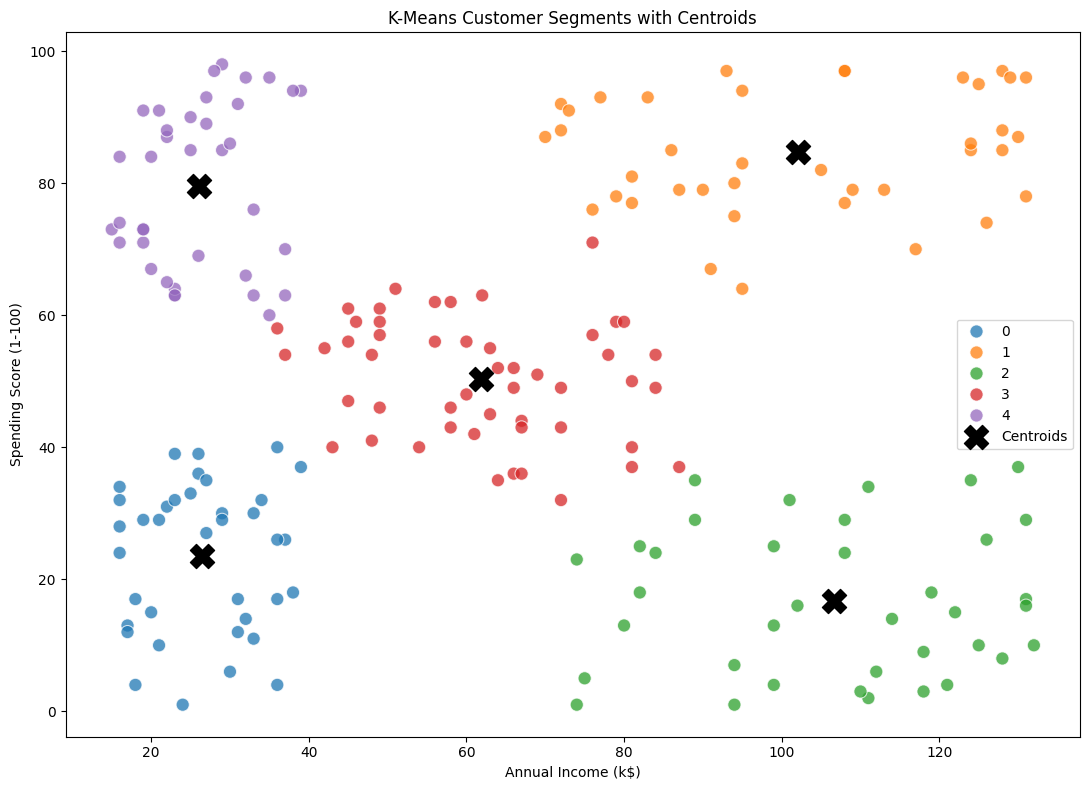

In [37]:
# Convert centroids back to original scale

centers_original = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=90,
    alpha=0.75
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=300,
    c="black",
    label="Centroids"
)

plt.title(
    "K-Means Customer Segments with Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.tight_layout()
plt.show()

## 10. PCA for Cluster Visualization

Principal Component Analysis (PCA) is used for dimensionality reduction and cluster visualization.

PCA transforms the scaled features into principal components while preserving as much variation as possible.

This helps visualize the customer clusters in a reduced feature space.

In [38]:
# Apply PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["Cluster"].values
})

print("Explained Variance Ratio:")
print(
    pca.explained_variance_ratio_
)

print(
    "\nTotal Explained Variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

pca_df.head()

Explained Variance Ratio:
[0.51255857 0.48744143]

Total Explained Variance: 1.0


,PC1,PC2,Cluster
0,-0.786008,-0.359519,4
1,-1.420223,-0.456041,4
2,0.868262,-0.513855,2
3,-0.600904,-0.467703,3
4,-0.445824,-1.045841,0


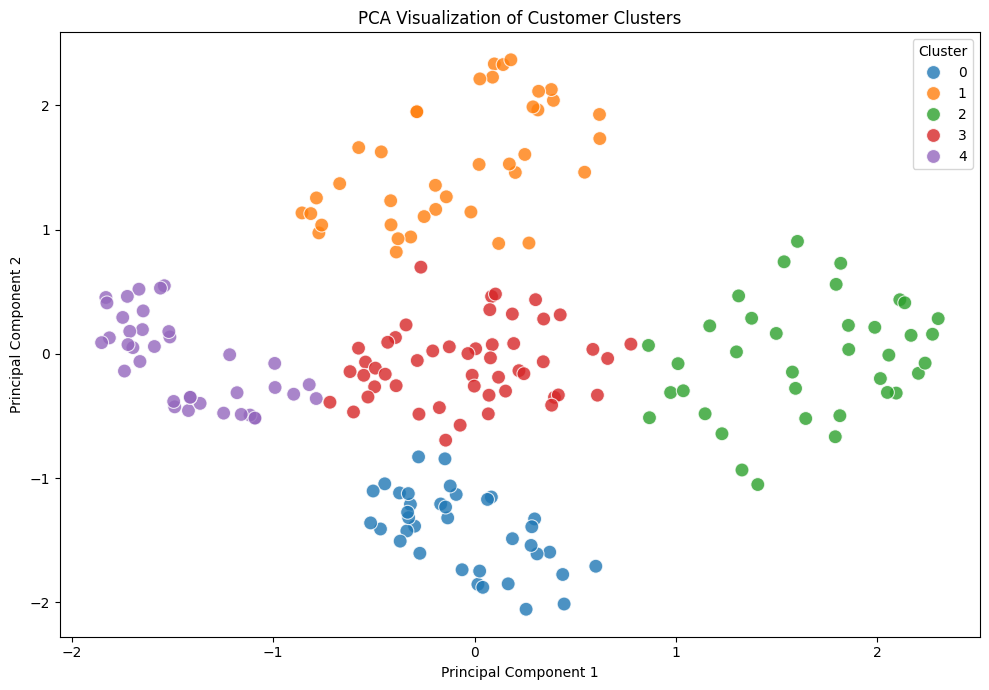

In [39]:
# PCA cluster visualization

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=100,
    alpha=0.8
)

plt.title(
    "PCA Visualization of Customer Clusters"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

## 11. Customer Segment Profiling

Each customer cluster is analyzed to understand its characteristics.

The profiling process examines:

- Average Age
- Average Annual Income
- Average Spending Score
- Number of Customers

This converts machine learning clusters into meaningful business segments.

In [40]:
# Create cluster profile

cluster_profile = df.groupby(
    "Cluster"
).agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).round(2)

cluster_profile = cluster_profile.rename(
    columns={
        "CustomerID": "Customer Count"
    }
)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,38.70,26.43,23.49,37
1,39.51,102.03,84.69,39
2,39.41,106.68,16.76,37
3,39.64,61.80,50.38,50
4,38.78,26.03,79.57,37


In [41]:
# Calculate overall averages

overall_income_mean = df[
    "Annual Income (k$)"
].mean()

overall_spending_mean = df[
    "Spending Score (1-100)"
].mean()

print(
    "Overall Average Income:",
    round(overall_income_mean, 2)
)

print(
    "Overall Average Spending Score:",
    round(overall_spending_mean, 2)
)

Overall Average Income: 64.78
Overall Average Spending Score: 51.28


## 12. Marketing Strategies for Customer Segments

Each identified customer segment is interpreted based on:

- Average income
- Average spending behavior
- Customer value
- Engagement potential

Relevant marketing strategies are proposed for each segment.

In [42]:
# Create evidence-based marketing strategies

segment_interpretations = []

for cluster_id in cluster_profile.index:
    
    avg_income = cluster_profile.loc[
        cluster_id,
        "Annual Income (k$)"
    ]
    
    avg_spending = cluster_profile.loc[
        cluster_id,
        "Spending Score (1-100)"
    ]
    
    # High Income + High Spending
    if (
        avg_income >= overall_income_mean
        and
        avg_spending >= overall_spending_mean
    ):
        
        segment_name = "High-Value Customers"
        
        strategy = (
            "Offer VIP loyalty programs, premium products, "
            "exclusive access, personalized rewards, "
            "and priority services."
        )
    
    # High Income + Low Spending
    elif (
        avg_income >= overall_income_mean
        and
        avg_spending < overall_spending_mean
    ):
        
        segment_name = (
            "High-Income Low-Spending Customers"
        )
        
        strategy = (
            "Use personalized recommendations, "
            "premium product trials, targeted promotions, "
            "and re-engagement campaigns."
        )
    
    # Low Income + High Spending
    elif (
        avg_income < overall_income_mean
        and
        avg_spending >= overall_spending_mean
    ):
        
        segment_name = (
            "Active Value-Seeking Customers"
        )
        
        strategy = (
            "Offer loyalty rewards, affordable bundles, "
            "discount programs, and frequent-purchase incentives."
        )
    
    # Low Income + Low Spending
    else:
        
        segment_name = (
            "Low-Engagement Customers"
        )
        
        strategy = (
            "Use budget-friendly promotions, "
            "entry-level offers, discount campaigns, "
            "and low-cost digital engagement."
        )
    
    segment_interpretations.append({
        "Cluster": cluster_id,
        "Average Income": round(
            avg_income,
            2
        ),
        "Average Spending Score": round(
            avg_spending,
            2
        ),
        "Segment Name": segment_name,
        "Recommended Marketing Strategy": strategy
    })

segment_strategy_df = pd.DataFrame(
    segment_interpretations
)

segment_strategy_df

,Cluster,Average Income,Average Spending Score,Segment Name,Recommended Marketing Strategy
0,0,26.43,23.49,Low-Engagement Customers,"Use budget-friendly promotions, entry-level of..."
1,1,102.03,84.69,High-Value Customers,"Offer VIP loyalty programs, premium products, ..."
2,2,106.68,16.76,High-Income Low-Spending Customers,"Use personalized recommendations, premium prod..."
3,3,61.80,50.38,Low-Engagement Customers,"Use budget-friendly promotions, entry-level of..."
4,4,26.03,79.57,Active Value-Seeking Customers,"Offer loyalty rewards, affordable bundles, dis..."


In [43]:
# Add segment names to original dataset

cluster_to_segment = dict(
    zip(
        segment_strategy_df["Cluster"],
        segment_strategy_df["Segment Name"]
    )
)

df["Segment Name"] = df[
    "Cluster"
].map(
    cluster_to_segment
)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment Name
0,1,Male,52,35,60,4,Active Value-Seeking Customers
1,2,Male,68,16,71,4,Active Value-Seeking Customers
2,3,Female,54,74,23,2,High-Income Low-Spending Customers
3,4,Female,38,37,54,3,Low-Engagement Customers
4,5,Female,18,26,39,0,Low-Engagement Customers


In [44]:
# Display segment distribution

segment_distribution = (
    df["Segment Name"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "Segment Name",
    "Number of Customers"
]

segment_distribution

,Segment Name,Number of Customers
0,Low-Engagement Customers,87
1,High-Value Customers,39
2,Active Value-Seeking Customers,37
3,High-Income Low-Spending Customers,37


## 13. Final Cluster Evaluation

The final clustering solution is evaluated using the Silhouette Score.

A higher Silhouette Score generally indicates:

- Better separation between clusters
- Greater similarity among customers within the same cluster

The score is interpreted together with visual separation and business usefulness.

In [45]:
# Calculate final Silhouette Score

final_silhouette_score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print(
    "Final Silhouette Score:",
    round(
        final_silhouette_score,
        4
    )
)

Final Silhouette Score: 0.5212


## 14. Save Customer Segmentation Results

The final customer dataset is exported with:

- Cluster labels
- Business-friendly segment names

The output can support further business analysis and targeted marketing campaigns.

In [46]:
# Save final results

output_file = (
    "customer_segmentation_results.csv"
)

df.to_csv(
    output_file,
    index=False
)

print(
    "Results saved successfully as:",
    output_file
)

Results saved successfully as: customer_segmentation_results.csv


## 15. Final Conclusion

This project applied unsupervised machine learning to segment mall customers based on their annual income and spending behavior.

The project successfully included:

- Dataset loading and inspection
- Data cleaning and preprocessing
- Exploratory Data Analysis
- Feature selection
- Feature scaling
- K-Means Clustering
- Elbow Method analysis
- Silhouette Score evaluation
- PCA-based cluster visualization
- Customer segment profiling
- Marketing strategy development

The K-Means algorithm identified distinct groups of customers with different income and spending characteristics.

PCA was used to visualize the customer segments in a reduced-dimensional space.

The cluster profiles were translated into meaningful business segments, and targeted marketing strategies were proposed according to the characteristics of each identified group.

High-value customers can be targeted with premium services and loyalty programs. High-income but lower-spending customers may benefit from personalized recommendations and re-engagement campaigns. Active value-seeking customers can be encouraged through bundles and loyalty rewards, while lower-engagement customers may respond to budget-friendly promotions.

Overall, this project demonstrates how K-Means Clustering, PCA, and customer profiling can support data-driven marketing strategies and better business decision-making.